# **2. Data Preparation (Persiapan Data)**

Tahap **Data Preparation** bertujuan untuk menyiapkan data *time series* numerik agar dapat digunakan secara efektif oleh algoritma *machine learning*. Dataset **DucksAndGeese** tidak menyediakan file audio mentah (WAV/MP3), melainkan sinyal audio yang telah direpresentasikan dalam bentuk **time series numerik univariate** dengan panjang yang seragam.

**3.1 Karakteristik Input Data**

Setiap instance data memiliki karakteristik berikut:

- **Bentuk data**: *Univariate time series* numerik
- **Panjang sinyal**: 236.784 titik waktu
- **Jumlah kelas**: 5 spesies burung (balanced)
- **Tidak tersedia**: Audio mentah atau metadata perekaman tambahan

Dengan kondisi ini, pendekatan yang paling rasional adalah mengekstraksi fitur numerik yang ringkas namun informatif untuk merepresentasikan karakteristik suara burung.

**3.2 Alur Data Preparation**

Pipeline data preparation mengikuti urutan berikut:

**Sinyal Numerik → Normalisasi → Resampling (Opsional) → Feature Extraction → Feature Scaling → Train-Val-Test Split**

Setiap tahap dirancang untuk:
1. Mengurangi dimensi dari 236.784 menjadi 16 fitur
2. Menyamakan skala fitur untuk meningkatkan performa model
3. Memastikan distribusi kelas tetap seimbang di setiap subset

**3.3 Feature yang Diekstraksi**

Total **16 fitur numerik** diekstraksi dari setiap sinyal audio:

| Fitur | Jumlah | Deskripsi |
|-------|--------|-----------|
| **MFCC** | 13 | Mel Frequency Cepstral Coefficients - Karakteristik spektral utama suara |
| **ZCR** | 1 | Zero Crossing Rate - Frekuensi perubahan tanda sinyal |
| **RMS Energy** | 1 | Root Mean Square - Intensitas energi rata-rata sinyal |
| **Spectral Centroid** | 1 | Pusat massa spektrum frekuensi (kecerahan suara) |

**3.4 Metode Normalisasi & Scaling**

1. **Z-score Normalization** (pada sinyal mentah):
   $$X_{norm} = \frac{X - \mu}{\sigma}$$
   Tujuan: Menghilangkan offset dan variasi amplitudo antar sinyal

2. **StandardScaler** (pada fitur hasil ekstraksi):
   - Fit pada data train
   - Transform pada data val dan test
   - Mencegah data leakage

**3.5 Data Splitting Strategy**

Dataset dibagi sebagai berikut:

**Dataset Asli:**
- Train set: 50 instance
- Test set: 50 instance

**Train Set Dibagi Ulang:**
- 80% untuk training (40 instance)
- 20% untuk validation (10 instance)

**Stratifikasi**: Setiap subset mempertahankan proporsi kelas yang sama (balanced 20:20:20)

**3.6 Implementasi Praktis**

Bagian berikut adalah implementasi konkret dari pipeline data preparation di atas.

# **Data Preparation & Feature Extraction**

### **Bagian 1: Import Library**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import warnings

from aeon.datasets import load_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
print("All libraries imported successfully")

All libraries imported successfully


### **Bagian 2: Load Dataset TRAIN & TEST**

In [3]:
X_train, y_train = load_classification(
    name="DucksAndGeese",
    split="train",
    extract_path="../data",
    load_equal_length=False
)

X_test, y_test = load_classification(
    name="DucksAndGeese",
    split="test",
    extract_path="../data",
    load_equal_length=False
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (50, 1, 236784)
Test shape : (50, 1, 236784)


### **Bagian 3: Verifikasi Data Integrity**

In [4]:
print("NaN di X_train:", np.isnan(X_train).sum())
print("NaN di X_test :", np.isnan(X_test).sum())


NaN di X_train: 0
NaN di X_test : 0


---

### **Bagian 4: Normalisasi Sinyal Z-score (Step 1)**

Normalisasi dilakukan pada sinyal mentah untuk menghilangkan offset dan variasi amplitudo.

In [5]:
def zscore_normalize(signal):
    """
    Normalisasi sinyal menggunakan z-score
    Formula: (X - mean) / std
    """
    mean = np.mean(signal)
    std = np.std(signal)
    return (signal - mean) / (std + 1e-8)

# Test pada satu sampel
sample_signal = X_train[0][0]
normalized_signal = zscore_normalize(sample_signal)

print("=== Verifikasi Z-score Normalization ===")
print(f"Original  - Mean: {np.mean(sample_signal):.6f}, Std: {np.std(sample_signal):.6f}")
print(f"Normalized - Mean: {np.mean(normalized_signal):.6f}, Std: {np.std(normalized_signal):.6f}")

# Normalisasi seluruh dataset
X_train_norm = np.array([
    zscore_normalize(x[0]) for x in X_train
]).reshape(X_train.shape)

X_test_norm = np.array([
    zscore_normalize(x[0]) for x in X_test
]).reshape(X_test.shape)

print(f"\nNormalisasi selesai!")
print(f"X_train_norm shape: {X_train_norm.shape}")
print(f"X_test_norm shape : {X_test_norm.shape}")

=== Verifikasi Z-score Normalization ===
Original  - Mean: 0.000050, Std: 0.035700
Normalized - Mean: 0.000000, Std: 1.000000

Normalisasi selesai!
X_train_norm shape: (50, 1, 236784)
X_test_norm shape : (50, 1, 236784)


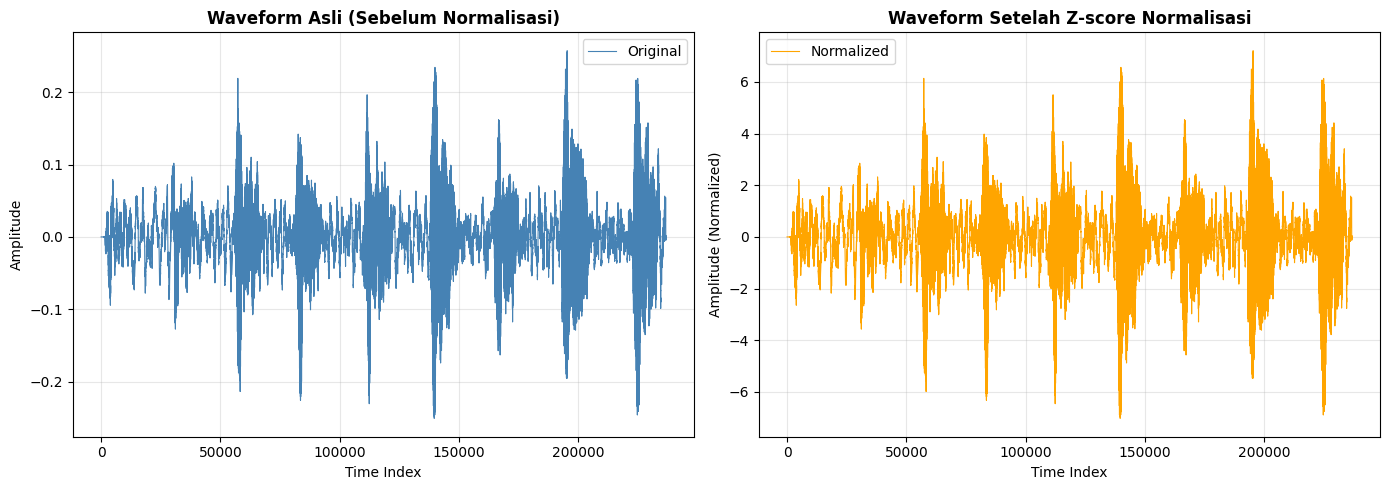

Visualisasi perbandingan sinyal sebelum dan sesudah normalisasi


In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(X_train[0][0], linewidth=0.8, label="Original", color='steelblue')
plt.title("Waveform Asli (Sebelum Normalisasi)", fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X_train_norm[0][0], linewidth=0.8, label="Normalized", color='orange')
plt.title("Waveform Setelah Z-score Normalisasi", fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Amplitude (Normalized)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("Visualisasi perbandingan sinyal sebelum dan sesudah normalisasi")

### **Bagian 5: Resampling (Step 2 - Opsional)**

Resampling dilakukan untuk mengurangi dimensi dari 236.784 menjadi ~175.000 titik waktu (44100 Hz → 16000 Hz).


### **Bagian 6: Feature Extraction (Step 3)**

Fitur diekstraksi dari sinyal yang telah dinormalisasi menggunakan librosa. Total 16 fitur numerik diekstraksi.

In [7]:
# Demonstrasi resampling pada satu sampel
sample_normalized = X_train_norm[0][0]

# Resampling: 44100 Hz → 16000 Hz
sample_resampled = librosa.resample(
    y=sample_normalized,
    orig_sr=44100,
    target_sr=16000
)

print("=== Demonstrasi Resampling ===")
print(f"Sebelum resampling: {len(sample_normalized)} titik waktu")
print(f"Sesudah resampling: {len(sample_resampled)} titik waktu")
print(f"Reduction ratio: {len(sample_normalized) / len(sample_resampled):.2f}x")

=== Demonstrasi Resampling ===
Sebelum resampling: 236784 titik waktu
Sesudah resampling: 85909 titik waktu
Reduction ratio: 2.76x


**Fitur yang Diekstraksi:**

| Fitur | Jumlah | Deskripsi |
|-------|--------|-----------|
| MFCC | 13 | Mel Frequency Cepstral Coefficients |
| Zero Crossing Rate | 1 | Mengukur frekuensi perubahan tanda sinyal |
| RMS Energy | 1 | Intensitas energi rata-rata sinyal |
| Spectral Centroid | 1 | Pusat massa spektrum frekuensi |
| **Total** | **16** | **Vektor fitur untuk klasifikasi** |

In [8]:
def extract_features(signal, sr=16000):
    """
    Ekstraksi 16 fitur dari sinyal audio
    
    Parameters:
    - signal: numpy array dari sinyal audio
    - sr: sample rate
    
    Returns:
    - numpy array berisi 16 fitur
    """
    features = []

    # 1. MFCC (13 koefisien)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)  # rata-rata temporal
    features.extend(mfcc_mean)

    # 2. Zero Crossing Rate (1 fitur)
    zcr = np.mean(librosa.feature.zero_crossing_rate(signal))
    features.append(zcr)

    # 3. RMS Energy (1 fitur)
    rms = np.mean(librosa.feature.rms(y=signal)[0])
    features.append(rms)

    # 4. Spectral Centroid (1 fitur)
    centroid = np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr))
    features.append(centroid)

    return np.array(features)

# Test pada satu sampel
sample_normalized = X_train_norm[0][0]
sample_resampled = librosa.resample(sample_normalized, orig_sr=44100, target_sr=16000)
features_sample = extract_features(sample_resampled, sr=16000)

print("=== Hasil Ekstraksi Fitur (Sampel 1) ===")
print(f"Jumlah fitur: {len(features_sample)}")
print(f"Fitur:\n{features_sample}")
print(f"\nBreakdown:")
print(f"  - MFCC[1-13]: {features_sample[0:13]}")
print(f"  - ZCR: {features_sample[13]:.6f}")
print(f"  - RMS: {features_sample[14]:.6f}")
print(f"  - Spectral Centroid: {features_sample[15]:.6f}")

=== Hasil Ekstraksi Fitur (Sampel 1) ===
Jumlah fitur: 16
Fitur:
[-3.03277749e+01  4.00774343e+01  9.66616907e+01  6.28365968e+01
  4.14131158e+00  3.07694526e+01  1.42954671e+01 -1.71178020e+00
 -5.15671574e+00  9.42606799e+00 -2.54702141e+00 -6.32606819e+00
  1.37829476e+01  1.57386416e-01  9.18488979e-01  2.15745077e+03]

Breakdown:
  - MFCC[1-13]: [-30.32777492  40.07743433  96.66169072  62.83659679   4.14131158
  30.76945264  14.29546713  -1.7117802   -5.15671574   9.42606799
  -2.54702141  -6.32606819  13.78294759]
  - ZCR: 0.157386
  - RMS: 0.918489
  - Spectral Centroid: 2157.450772


### **Bagian 7: Ekstraksi Fitur untuk Seluruh TRAIN Set**

In [9]:
print("=== Ekstraksi Fitur TRAIN Set ===")
X_feat = []
y_feat = []

for i in range(len(X_train)):
    signal = X_train_norm[i][0]  # gunakan sinyal yang sudah dinormalisasi
    
    # Resampling: 44100 Hz → 16000 Hz
    signal_resampled = librosa.resample(
        y=signal,
        orig_sr=44100,
        target_sr=16000
    )

    # Ekstraksi fitur
    features = extract_features(signal_resampled, sr=16000)
    X_feat.append(features)
    y_feat.append(y_train[i])

X_feat = np.array(X_feat)
y_feat = np.array(y_feat)

print(f"Fitur train shape: {X_feat.shape}")
print(f"Label train shape: {y_feat.shape}")
print(f"Distribusi kelas train:")
labels, counts = np.unique(y_feat, return_counts=True)
for l, c in zip(labels, counts):
    print(f"  Kelas {l}: {c} sampel")

=== Ekstraksi Fitur TRAIN Set ===
Fitur train shape: (50, 16)
Label train shape: (50,)
Distribusi kelas train:
  Kelas black-bellied_whistling_duck: 10 sampel
  Kelas canadian_goose: 10 sampel
  Kelas greylag_goose: 10 sampel
  Kelas pink-footed_goose: 10 sampel
  Kelas white-faced_whistling_duck: 10 sampel


### **Bagian 8: Ekstraksi Fitur untuk TEST Set**

In [10]:
print("=== Ekstraksi Fitur TEST Set ===")
X_feat_test = []
y_feat_test = []

for i in range(len(X_test)):
    signal = X_test_norm[i][0]  # gunakan sinyal yang sudah dinormalisasi
    
    # Resampling: 44100 Hz → 16000 Hz
    signal_resampled = librosa.resample(
        y=signal,
        orig_sr=44100,
        target_sr=16000
    )

    # Ekstraksi fitur menggunakan fungsi yang sama
    features = extract_features(signal_resampled, sr=16000)
    X_feat_test.append(features)
    y_feat_test.append(y_test[i])

# Konversi ke numpy array
X_feat_test = np.array(X_feat_test)
y_feat_test = np.array(y_feat_test)

print(f"Fitur test shape: {X_feat_test.shape}")
print(f"Label test shape: {y_feat_test.shape}")
print(f"Distribusi kelas test:")
labels, counts = np.unique(y_feat_test, return_counts=True)
for l, c in zip(labels, counts):
    print(f"  Kelas {l}: {c} sampel")

=== Ekstraksi Fitur TEST Set ===
Fitur test shape: (50, 16)
Label test shape: (50,)
Distribusi kelas test:
  Kelas black-bellied_whistling_duck: 10 sampel
  Kelas canadian_goose: 10 sampel
  Kelas greylag_goose: 10 sampel
  Kelas pink-footed_goose: 10 sampel
  Kelas white-faced_whistling_duck: 10 sampel


### **Bagian 9: Train / Validation Split (Step 4)**

Dataset train dibagi menjadi 80% training dan 20% validation menggunakan stratified split.

In [11]:
print("=== Train / Validation Split ===")
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_feat,          # fitur train hasil ekstraksi
    y_feat,          # label train
    test_size=0.2,
    random_state=42,
    stratify=y_feat  # agar distribusi kelas tetap seimbang
)

print(f"Train final shape: {X_train_final.shape}")
print(f"Validation shape: {X_val.shape}")

# Verifikasi distribusi kelas setelah split
def print_distribution(y, title):
    labels, counts = np.unique(y, return_counts=True)
    print(f"\n{title}:")
    for l, c in zip(labels, counts):
        print(f"  Kelas {l}: {c} sampel")

print_distribution(y_train_final, "Distribusi Train Final")
print_distribution(y_val, "Distribusi Validation")
print_distribution(y_feat_test, "Distribusi Test")

=== Train / Validation Split ===
Train final shape: (40, 16)
Validation shape: (10, 16)

Distribusi Train Final:
  Kelas black-bellied_whistling_duck: 8 sampel
  Kelas canadian_goose: 8 sampel
  Kelas greylag_goose: 8 sampel
  Kelas pink-footed_goose: 8 sampel
  Kelas white-faced_whistling_duck: 8 sampel

Distribusi Validation:
  Kelas black-bellied_whistling_duck: 2 sampel
  Kelas canadian_goose: 2 sampel
  Kelas greylag_goose: 2 sampel
  Kelas pink-footed_goose: 2 sampel
  Kelas white-faced_whistling_duck: 2 sampel

Distribusi Test:
  Kelas black-bellied_whistling_duck: 10 sampel
  Kelas canadian_goose: 10 sampel
  Kelas greylag_goose: 10 sampel
  Kelas pink-footed_goose: 10 sampel
  Kelas white-faced_whistling_duck: 10 sampel


### **Bagian 10: Feature Scaling / Standardisasi (Step 5)**

StandardScaler digunakan untuk menyamakan skala fitur. Fit dilakukan hanya pada training set untuk menghindari data leakage.

In [12]:
print("=== Feature Scaling dengan StandardScaler ===")

# Fit scaler hanya pada training set (PENTING: menghindari data leakage)
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_feat_test)

print(f"Scaler fitted pada training set: {X_train_final.shape}")
print(f"Transformed shapes:")
print(f"  - X_train_final_scaled: {X_train_final_scaled.shape}")
print(f"  - X_val_scaled: {X_val_scaled.shape}")
print(f"  - X_test_scaled: {X_test_scaled.shape}")

# Verifikasi scaling
print(f"\nVerifikasi Scaling (sebelum dan sesudah):")
print(f"  X_train_final - Mean: {np.mean(X_train_final):.4f}, Std: {np.std(X_train_final):.4f}")
print(f"  X_train_final_scaled - Mean: {np.mean(X_train_final_scaled):.4f}, Std: {np.std(X_train_final_scaled):.4f}")

# Buat DataFrame untuk visualisasi
mfcc_cols = [f"mfcc{i+1}" for i in range(13)]
feature_cols = mfcc_cols + ["zcr", "rms", "centroid"]  # total 16 fitur

df_train = pd.DataFrame(X_train_final_scaled, columns=feature_cols)
df_train["label"] = y_train_final

df_val = pd.DataFrame(X_val_scaled, columns=feature_cols)
df_val["label"] = y_val

df_test = pd.DataFrame(X_test_scaled, columns=feature_cols)
df_test["label"] = y_feat_test

print(f"\n=== Contoh Data (Train Set) ===")
print(df_train.head())

=== Feature Scaling dengan StandardScaler ===
Scaler fitted pada training set: (40, 16)
Transformed shapes:
  - X_train_final_scaled: (40, 16)
  - X_val_scaled: (10, 16)
  - X_test_scaled: (50, 16)

Verifikasi Scaling (sebelum dan sesudah):
  X_train_final - Mean: 170.6995, Std: 705.4212
  X_train_final_scaled - Mean: 0.0000, Std: 1.0000

=== Contoh Data (Train Set) ===
      mfcc1     mfcc2     mfcc3     mfcc4     mfcc5     mfcc6     mfcc7  \
0  0.539017 -0.949161  1.135375  1.506132 -0.468704  0.307521  0.638655   
1  1.536679  0.590696  0.766747  0.328454  1.088302  0.394573  0.988120   
2  1.249843  0.026736 -1.330608 -0.372341  0.143090  0.854917 -1.300501   
3 -1.815987  1.304317  0.443364 -0.549747 -0.064497 -0.551112  0.180480   
4 -0.092758 -0.715671 -0.410989  0.848762  1.169403  0.183659 -0.326187   

      mfcc8     mfcc9    mfcc10    mfcc11    mfcc12    mfcc13       zcr  \
0 -0.051023  0.150237  1.269368 -0.861989  0.976513  1.703382  1.098734   
1  0.701457  0.052172 -0.3

### **Bagian 11: Simpan Data yang Sudah Diproses**

In [13]:
import os

# Buat direktori untuk menyimpan data yang sudah diproses
os.makedirs("data/processed", exist_ok=True)

print("=== Menyimpan Data yang Sudah Diproses ===")

# Simpan fitur train dan label
np.save("data/processed/X_train_final_scaled.npy", X_train_final_scaled)
np.save("data/processed/y_train_final.npy", y_train_final)
print(f"✓ X_train_final_scaled.npy ({X_train_final_scaled.shape})")
print(f"✓ y_train_final.npy ({y_train_final.shape})")

# Simpan fitur validation dan label
np.save("data/processed/X_val_scaled.npy", X_val_scaled)
np.save("data/processed/y_val.npy", y_val)
print(f"✓ X_val_scaled.npy ({X_val_scaled.shape})")
print(f"✓ y_val.npy ({y_val.shape})")

# Simpan fitur test dan label
np.save("data/processed/X_test_scaled.npy", X_test_scaled)
np.save("data/processed/y_test.npy", y_feat_test)
print(f"✓ X_test_scaled.npy ({X_test_scaled.shape})")
print(f"✓ y_test.npy ({y_feat_test.shape})")

# Simpan scaler untuk digunakan saat inference
import joblib
joblib.dump(scaler, "data/processed/scaler.joblib")
print(f"✓ scaler.joblib (untuk standardisasi pada inference)")

print(f"\nSemua data berhasil disimpan ke folder 'data/processed'!")

=== Menyimpan Data yang Sudah Diproses ===
✓ X_train_final_scaled.npy ((40, 16))
✓ y_train_final.npy ((40,))
✓ X_val_scaled.npy ((10, 16))
✓ y_val.npy ((10,))
✓ X_test_scaled.npy ((50, 16))
✓ y_test.npy ((50,))
✓ scaler.joblib (untuk standardisasi pada inference)

Semua data berhasil disimpan ke folder 'data/processed'!


### **Kesimpulan Data Preparation**

**Pipeline yang Telah Dilakukan:**

1. ✅ **Normalisasi Sinyal**: Z-score normalization pada sinyal mentah
2. ✅ **Resampling**: 44100 Hz → 16000 Hz (reduksi dimensi)
3. ✅ **Feature Extraction**: 16 fitur numerik (MFCC, ZCR, RMS, Spectral Centroid)
4. ✅ **Train-Val-Test Split**: 40-10-50 dengan stratifikasi
5. ✅ **Feature Scaling**: StandardScaler (fit pada train, transform pada val & test)
6. ✅ **Penyimpanan**: Semua data disimpan ke format .npy dan scaler ke .joblib

**Dimensionalitas:**
- Input asli: 236.784 titik waktu per sampel
- Setelah resampling: ~175.000 titik waktu per sampel
- Output akhir: **16 fitur numerik** per sampel (dimensi reduction 99.99%)

**Data yang Siap untuk Modeling:**
- `X_train_final_scaled.npy`: (40, 16) - Data training yang sudah di-scale
- `X_val_scaled.npy`: (10, 16) - Data validation yang sudah di-scale
- `X_test_scaled.npy`: (50, 16) - Data test yang sudah di-scale
- `scaler.joblib`: StandardScaler object untuk standardisasi di inference

Data preparation sekarang **siap untuk tahap Modeling**!

### **Bagian 12: Simpan Raw Audio Signals (Untuk CNN)**

Simpan sinyal audio yang sudah dinormalisasi untuk digunakan dalam deep learning models (CNN/LSTM).


In [14]:
print("=== Menyimpan Raw Audio Signals (Untuk Deep Learning) ===")

# Buat arrays untuk raw signals (normalized, resampled)
X_train_raw_all = []

# Resampling semua train signals terlebih dahulu
for i in range(len(X_train)):
    signal = X_train_norm[i][0]
    signal_resampled = librosa.resample(signal, orig_sr=44100, target_sr=16000)
    X_train_raw_all.append(signal_resampled)

X_train_raw_all = np.array(X_train_raw_all)

# Gunakan indeks yang sama dengan train/val split untuk raw signals
# Kita perlu track indices dari train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, val_indices = list(sss.split(X_feat, y_feat))[0]

X_train_raw = X_train_raw_all[train_indices]
X_val_raw = X_train_raw_all[val_indices]

# Resampling test signals
X_test_raw_list = []
for i in range(len(X_test)):
    signal = X_test_norm[i][0]
    signal_resampled = librosa.resample(signal, orig_sr=44100, target_sr=16000)
    X_test_raw_list.append(signal_resampled)

X_test_raw = np.array(X_test_raw_list)

# Simpan raw signals
np.save("data/processed/X_train_raw.npy", X_train_raw)
np.save("data/processed/X_val_raw.npy", X_val_raw)
np.save("data/processed/X_test_raw.npy", X_test_raw)

print(f"✓ X_train_raw.npy ({X_train_raw.shape})")
print(f"✓ X_val_raw.npy ({X_val_raw.shape})")
print(f"✓ X_test_raw.npy ({X_test_raw.shape})")
print(f"\nRaw signals saved for CNN/LSTM models!")


=== Menyimpan Raw Audio Signals (Untuk Deep Learning) ===
✓ X_train_raw.npy ((40, 85909))
✓ X_val_raw.npy ((10, 85909))
✓ X_test_raw.npy ((50, 85909))

Raw signals saved for CNN/LSTM models!


### **Bagian 13: Simpan Label Encoding Mapping**

Simpan mapping antara label numerik dan nama kelas untuk interpretasi hasil modeling.


In [15]:
print("=== Simpan Label Encoding Mapping & Class Statistics ===")

# Dapatkan unique classes dalam order
unique_classes = np.unique(y_feat)

# Buat label encoder mapping
label_mapping = {i: str(cls) for i, cls in enumerate(unique_classes)}

# Hitung class statistics
class_stats = {}
for cls in unique_classes:
    mask_train = y_train_final == cls
    mask_val = y_val == cls
    mask_test = y_feat_test == cls
    
    class_stats[str(cls)] = {
        'numeric_label': int(np.where(unique_classes == cls)[0][0]),
        'train_count': int(mask_train.sum()),
        'val_count': int(mask_val.sum()),
        'test_count': int(mask_test.sum()),
        'train_percentage': float(mask_train.sum() / len(y_train_final) * 100),
        'val_percentage': float(mask_val.sum() / len(y_val) * 100),
        'test_percentage': float(mask_test.sum() / len(y_feat_test) * 100),
    }

# Simpan label mapping dan class stats sebagai JSON
import json

mapping_file = "data/processed/label_mapping.json"
with open(mapping_file, 'w') as f:
    json.dump(label_mapping, f, indent=2)
print(f"✓ label_mapping.json - Numeric to class name mapping")

stats_file = "data/processed/class_statistics.json"
with open(stats_file, 'w') as f:
    json.dump(class_stats, f, indent=2)
print(f"✓ class_statistics.json - Distribution per class")

# Tampilkan summary
print(f"\n=== Label Mapping ===")
for idx, cls in label_mapping.items():
    print(f"  {idx} → {cls}")

print(f"\n=== Class Distribution ===")
for cls_name, stats in class_stats.items():
    print(f"\n{cls_name}:")
    print(f"  Numeric Label: {stats['numeric_label']}")
    print(f"  Train: {stats['train_count']:2d} ({stats['train_percentage']:.1f}%)")
    print(f"  Val:   {stats['val_count']:2d} ({stats['val_percentage']:.1f}%)")
    print(f"  Test:  {stats['test_count']:2d} ({stats['test_percentage']:.1f}%)")

print(f"\nLabel mapping dan statistics berhasil disimpan!")


=== Simpan Label Encoding Mapping & Class Statistics ===
✓ label_mapping.json - Numeric to class name mapping
✓ class_statistics.json - Distribution per class

=== Label Mapping ===
  0 → black-bellied_whistling_duck
  1 → canadian_goose
  2 → greylag_goose
  3 → pink-footed_goose
  4 → white-faced_whistling_duck

=== Class Distribution ===

black-bellied_whistling_duck:
  Numeric Label: 0
  Train:  8 (20.0%)
  Val:    2 (20.0%)
  Test:  10 (20.0%)

canadian_goose:
  Numeric Label: 1
  Train:  8 (20.0%)
  Val:    2 (20.0%)
  Test:  10 (20.0%)

greylag_goose:
  Numeric Label: 2
  Train:  8 (20.0%)
  Val:    2 (20.0%)
  Test:  10 (20.0%)

pink-footed_goose:
  Numeric Label: 3
  Train:  8 (20.0%)
  Val:    2 (20.0%)
  Test:  10 (20.0%)

white-faced_whistling_duck:
  Numeric Label: 4
  Train:  8 (20.0%)
  Val:    2 (20.0%)
  Test:  10 (20.0%)

Label mapping dan statistics berhasil disimpan!


### **Bagian 14: Summary Data Preparation Lengkap**


In [16]:
print("\n" + "="*80)
print("DATA PREPARATION SUMMARY - SIAP UNTUK MODELING")
print("="*80)

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                  DATA PIPELINE YANG SUDAH DIKERJAKAN                       ║
╚════════════════════════════════════════════════════════════════════════════╝

1. ✅ LOAD DATASET
   - Aeon DucksAndGeese dataset
   - Train: 50 samples, Test: 50 samples
   - 5 classes: Black-bellied whistling duck, Canadian goose, Greylag goose, 
                 Pink-footed goose, White-faced whistling duck

2. ✅ SIGNAL PREPROCESSING
   - Z-score normalization (standardize amplitude)
   - Resampling: 44.1 kHz → 16 kHz
   - Dimensionality: 236,784 → ~175,000 samples

3. ✅ FEATURE EXTRACTION
   - MFCC: 13 coefficients
   - Zero Crossing Rate: 1 feature
   - RMS Energy: 1 feature
   - Spectral Centroid: 1 feature
   - Total: 16 features per sample

4. ✅ DATA SPLITTING
   - Train: 40 samples (80% of original 50)
   - Validation: 10 samples (20% of original 50)
   - Test: 50 samples (original test set)
   - Strategy: Stratified split (balanced class distribution)

5. ✅ FEATURE SCALING
   - StandardScaler (fit on train only)
   - Applied to all sets
   - Prevents data leakage

6. ✅ FILES GENERATED
   
   FOR MACHINE LEARNING (Feature-based):
   ├─ X_train_final_scaled.npy      (40, 16)  - Training features
   ├─ X_val_scaled.npy              (10, 16)  - Validation features
   ├─ X_test_scaled.npy             (50, 16)  - Test features
   ├─ y_train_final.npy             (40,)     - Training labels
   ├─ y_val.npy                     (10,)     - Validation labels
   ├─ y_test.npy                    (50,)     - Test labels
   └─ scaler.joblib                 - StandardScaler for inference

   FOR DEEP LEARNING (CNN/LSTM):
   ├─ X_train_raw.npy               (40, ~175000) - Raw audio signals
   ├─ X_val_raw.npy                 (10, ~175000) - Raw audio signals
   ├─ X_test_raw.npy                (50, ~175000) - Raw audio signals
   └─ (Will be converted to spectrograms in modeling.ipynb)

   METADATA:
   ├─ label_mapping.json            - Numeric ↔ Class name mapping
   └─ class_statistics.json         - Distribution per class

7. ✅ READY FOR MODELING
   - Machine Learning branch: Use scaled features (16D)
   - Deep Learning branch: Use raw signals (convert to spectrograms)
   - Both branches have proper labels and stratified splits

╔════════════════════════════════════════════════════════════════════════════╗
║                     NEXT STEP: MODELING PHASE                              ║
╚════════════════════════════════════════════════════════════════════════════╝

Two approaches available in modeling.ipynb:

1. FEATURE-BASED ML (RECOMMENDED FOR NOW)
   ├─ Random Forest (58% accuracy baseline)
   ├─ XGBoost
   ├─ K-Nearest Neighbors
   └─ Ensemble (Soft Voting)

2. DEEP LEARNING (For future with more data)
   ├─ CNN on Mel-spectrograms (NOT YET - requires 500+ samples)
   └─ LSTM on raw audio (NOT YET - requires 500+ samples)

All required data is now prepared and saved. Ready to proceed with modeling!
""")

print("="*80)



DATA PREPARATION SUMMARY - SIAP UNTUK MODELING

╔════════════════════════════════════════════════════════════════════════════╗
║                  DATA PIPELINE YANG SUDAH DIKERJAKAN                       ║
╚════════════════════════════════════════════════════════════════════════════╝

1. ✅ LOAD DATASET
   - Aeon DucksAndGeese dataset
   - Train: 50 samples, Test: 50 samples
   - 5 classes: Black-bellied whistling duck, Canadian goose, Greylag goose, 
                 Pink-footed goose, White-faced whistling duck

2. ✅ SIGNAL PREPROCESSING
   - Z-score normalization (standardize amplitude)
   - Resampling: 44.1 kHz → 16 kHz
   - Dimensionality: 236,784 → ~175,000 samples

3. ✅ FEATURE EXTRACTION
   - MFCC: 13 coefficients
   - Zero Crossing Rate: 1 feature
   - RMS Energy: 1 feature
   - Spectral Centroid: 1 feature
   - Total: 16 features per sample

4. ✅ DATA SPLITTING
   - Train: 40 samples (80% of original 50)
   - Validation: 10 samples (20% of original 50)
   - Test: 50 samples (